<img src="https://www.javeriana.edu.co/recursosdb/20125/5571273/escudo-circular.png" alt="Escudo Javeriana" style="float:left;">
<h1>Pontificia Universidad Javeriana</h1>

<h2>Taller Aplicación Metodología CRISP-DM - Grupo 10</h2>

###Integrantes:

* Diego Alejandro Torres Fortaleche
* Andres Rodolfo Quiroga Mejia
* Sergio Puentes Castillo
* Jorge Alejandro Sánchez Niño


## Metodologia CRISP-DM aplicada al churn bancario

Este cuaderno documenta de forma detallada la aplicacion paso a paso del marco CRISP-DM para analizar y modelar la desercion de clientes en un banco multiregion. Se reutiliza la estructura del cuaderno de referencia del modulo y se trabaja con el dataset `Bank_Customer_Churn_Prediction.csv`.

## 1. Comprension del negocio

### 1.1 Objetivo del proyecto
- Entender qué variables son determinantes para predecir la pérdida de clientes del banco ABC.
- Identificar patrones asociados a la desercion de clientes para priorizar acciones de retencion.
- Estimar la probabilidad de churn de cada cliente con modelos interpretable y de alto desempeño.

### 1.2 Contexto y alcance

- La retención de clientes es un aspecto esencial para la sostenibilidad de cualquier institución financiera. En un mercado altamente competitivo, los bancos buscan anticipar qué clientes podrían abandonar la entidad para diseñar estrategias preventivas y fortalecer la fidelización. El Banco ABC enfrenta este mismo desafío: comprender las razones que llevan a algunos clientes a cerrar sus cuentas y cambiar de entidad.

- El conjunto de datos disponible contiene información demográfica, financiera y de comportamiento de los clientes, lo que permite analizar distintos perfiles y sus patrones de permanencia o abandono. Entre las variables se incluyen indicadores como el puntaje crediticio, el país y el género del cliente, su edad, el tiempo que lleva vinculado al banco (tenure), el saldo promedio en su cuenta, el número de productos financieros contratados, si posee o no tarjeta de crédito, su nivel de actividad con la entidad y su salario estimado.

- A partir de esta información, el objetivo es aplicar la metodología CRISP-DM para predecir la probabilidad de abandono de un cliente, documentando en forma detallada todo el proceso.

### 1.3 Criterios de exito
- F1-score en datos de prueba mayor o igual a 0.60 para balancear precision y recall.
- Disponibilidad de dos modelos comparables con analisis de trade-offs.
- Documentacion del flujo CRISP-DM con insumos listos para socializar con las areas de negocio.

##2. Estudio y comprensión de datos

### 2.1.	Importar Librerías

> Se Importan paquetes de manejo de datos, modelamiento de algoritmos, procesamiento de datos, visualización y algunas configuraciones para visualización de datos.


In [1]:
#Instalar pandas-profiling para construir un resumen de la base de datos.
! pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip

  Using cached https://github.com/pandas-profiling/pandas-profiling/archive/master.zip
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


In [2]:
# Librerías base y configuración general
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

# Visualización
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

# Estilos visuales
%matplotlib inline
mpl.style.use('ggplot')
sns.set_style("whitegrid")
pylab.rcParams['figure.figsize'] = (8, 6)
plt.rcParams["figure.figsize"] = (8, 5)

# Análisis exploratorio
import ydata_profiling as pp

# Preprocesamiento y manejo de datos
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Normalizer, scale, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Selección y evaluación de modelos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Configuraciones adicionales
np.random.seed(42)



c:\Users\andres\anaconda3\envs\tensorflow\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### 2.2.	Funciones

> Estas no son funciones necesarías para entender los datos, pero ayuda a la legibilidad del código y limpieza de las secciones del código. Se tienen funciones que configuran y permiten ver rapidamente, histogramas, distribuciones, categorias, mapas de correlación, descripciones más completas de variables, entre otras.

In [3]:
## Esta función permite la representación de los datos en un gráfico que
## representa la distribución de los datos en un plano bidimensional.
## El mapa se construye ayudado con la función kdeplot (kernel density
## estimate KDE), que transforma los datos del eje Y en una curva de
## densidad de probabilidad contínua.
def plot_distribution(df, var, target, **kwargs):
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    facet = sns.FacetGrid(df, hue=target, aspect=4, row=row, col=col)
    facet.map(sns.kdeplot, var, fill=True)
    facet.set(xlim=(0, df[var].max()))
    facet.add_legend()

## Con esta función se puede graficar una representación de los datos en forma
## de barras, así lograr una mejor visualización de la información.
def plot_categories(df, cat, target, **kwargs):
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    order = sorted(df[cat].unique())

    facet = sns.FacetGrid(df, row=row, col=col)
    facet.map(sns.barplot, cat, target, order=order)
    facet.add_legend()

## La función genera una mapa de cuadros son se correlaciona la información
## contenida en el dataset.
def plot_correlation_map(df):
    # keep only numeric columns
    num = df.select_dtypes(include="number")
    if num.shape[1] == 0:
        raise ValueError("No numeric columns found to compute correlations.")

    corr = num.corr()  # or: num.corr(numeric_only=True) on pandas>=2
    _, ax = plt.subplots(figsize=(12, 10))
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(
        corr,
        cmap=cmap,
        square=True,
        cbar_kws={"shrink": 0.9},
        ax=ax,
        annot=True,
        annot_kws={"fontsize": 12}
    )

### 2.3.	Cargar la información

> En este punto se necesitan los datos a procesar, normalmente se usa un solo archivo para almacenar el dataset ya depurado. Sin embargo, en esta notebook se usa un conjunto de entrenamiento "train.csv" y otro para validación "test.csv". Lo ideal es subirlos al servidor de notebooks que se esté usando. Los archivos están en formato csv y serán integrados en un solo dataFrame para su exploración.


In [4]:
data_path = "Bank_Customer_Churn_Prediction.csv"
raw_df = pd.read_csv(data_path)
print("El DataFrame tiene", raw_df.shape[0], "filas y ", raw_df.shape[1], " columnas")

El DataFrame tiene 10000 filas y  12  columnas


In [5]:
## El dataset completo se compone de 10000 registros. Lo ideal entonces es reservar
## aproximadamente un 70% para entrenamiento, 20% para pruebas
## y 10% validación final.
print ('Dataset Completo: ' , '\n    banco:' , raw_df.shape)


## se hace un slice del dataframe completo hasta el registro 7000.
full = raw_df
banco_analysis = raw_df[ :7000 ]
## El dataframe banco_analysis contiene la información de entrenamiento.
## Vizualizar tamaños y numero de caracteristicas iniciales de cada uno
print ('Dataset entrenamiento: ' , '\n    full:' , banco_analysis.shape)

Dataset Completo:  
    banco: (10000, 12)
Dataset entrenamiento:  
    full: (7000, 12)


### 2.4.	Análisis estadístico

* En el set de datos para entrenamiento tenemos 7000 filas y 12 columnas. 11 variables más la variable objetivo 'churn'.

* Se evidencia que no tenemos valores perdidos.

In [6]:
## .head() Permite ver información general de los datos
banco_analysis.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
## .describe() Análisis de variables numéricas
banco_analysis.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,1.569070e+07,649.787000,38.892714,5.010286,76471.883751,1.526000,0.703286,0.512143,100631.400446,0.206143
std,7.157830e+04,97.046279,10.465562,2.887500,62403.383911,0.583047,0.456842,0.499888,57599.463109,0.404563
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.562860e+07,582.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51113.055000,0.000000
50%,1.569068e+07,651.000000,37.000000,5.000000,97277.130000,1.000000,1.000000,1.000000,100890.865000,0.000000
75%,1.575183e+07,717.000000,44.000000,7.250000,127537.155000,2.000000,1.000000,1.000000,149587.657500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


### Resumen del set de datos usando pandas profiling

Del perfil creado por la librería podemos observar:

* 3 alertas. La primera nos indica que la columna customer_id es un identificador. Esta columna no es útil para el análisis.También nos indica que en las columnas tenure y balance hay filas con valor 0. Representa que dentro del set de datos tenemos clientes sin dinero en sus cuentas y también clientes nuevos que aún no cumplen el primer año de antigüedad.

* Confirmamos que no hay valores perdidos.

* La variable credit_score presenta una distribución normal.

* En la variable country observamos que tenemos datos de Francia, España y Alemania. Francia tiene el 50.3% de los datos. El restante está repartido entre España y Alemania de manera equitativa.

* Hay una mayor representación de hombres en el data set. Una diferencia de 8.4% respecto a las mujeres.

* El histograma de la edad nos muestra que la mayoría de los clientes se encuentra entre los 25 y los 45 años.

* La antigüedad tiene una distribución uniforme y una media de 5 años.

* En el balance hay algo interesante y es que el 36.2% de los datos tienen valor cero. Es importante tener esto en cuenta, entender a qué se debe que existan tantas cuentas sin balance y validar cómo se relaciona esto con la variable objetivo.

* Solo el 3.3% de los clientes tienen más de dos productos con el banco.

* El 70.3% de los clientes tienen una tarjeta de crédito con el banco.

* El valor promedio de la variable salario estimado es de 100631.4

* La clase positiva representa cerca del 20 % de los registros, lo que exige usar metricas equilibradas como F1 y revisar el recall para no perder clientes valiosos.



In [8]:
#Resumir las características de la base de datos en un perfil (profile), nos proporciona un resumen de la base de datos que incluye el número de variables,
#el número de observaciones, el total de datos perdidos y el tipo de variable para cada columna del dataframe, además, incluye estadística descriptiva básica
#para cada variable

profile= pp.ProfileReport(banco_analysis,explorative=True,
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": False},
        "cramers": {"calculate": False},
    })
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 428.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## **De la matriz de correlación podemos osbervar que:**

* La correlación en general es baja, se encuentra por debajo de |0.3|. Esto nos indica que nuestras variables son en gran medida independientes. No hay redundancia y por tanto no hay necesidad de mezclar o eliminar variables por esta razón.

* Analizando la variable objetivo churn respecto a las otras variables observamos que la relación mas fuerte se da con la variable age. Clientes más viejos son más propensos a irse.

> Encontramos una correlación negativa con la variable active_member. Esto indica que clientes activos tienen menor tendencia a irse.

> Los clientes con un mayor balance presentan una mayor tendencia a irse. Es una relación ligera.

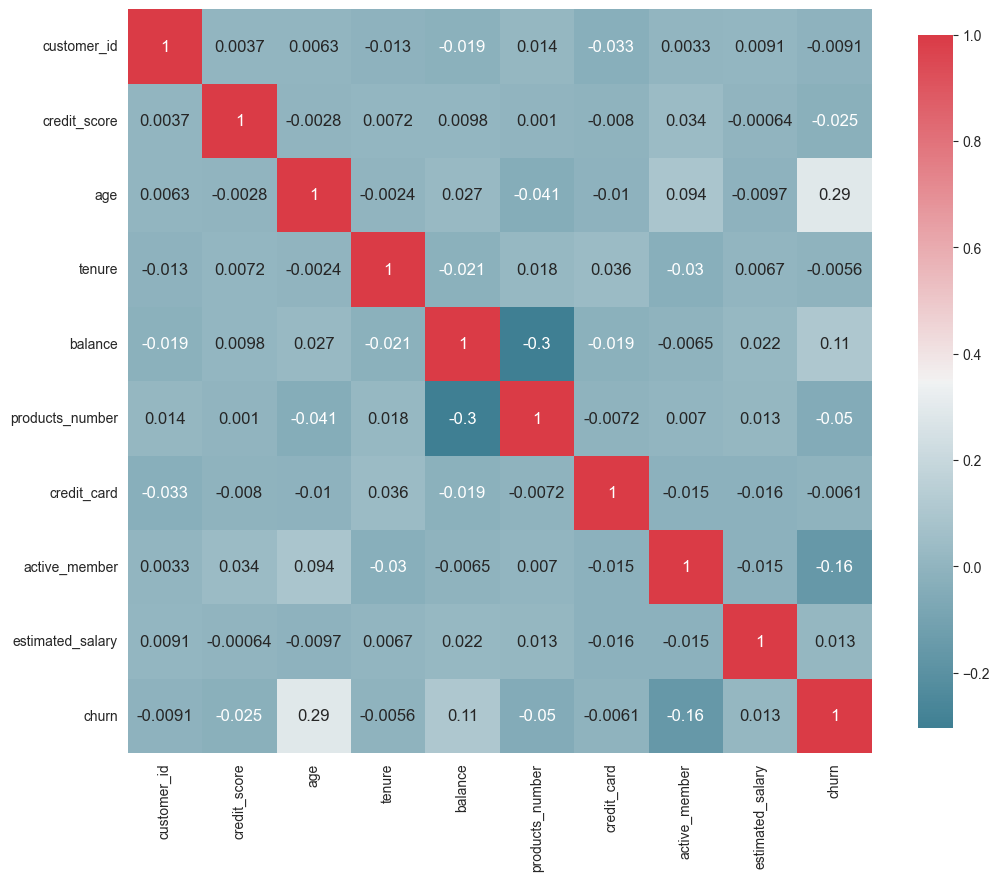

In [9]:
plot_correlation_map(banco_analysis)

## **De la aplicación del método KDE podemos osbervar que:**

* Para ambos géneros los clientes que se van son en promedio más viejos que los que se quedan.

* El pico de deserción está entre los 45 y 50 años mientras que el de retención está entre los 30 y los 35 años.

* Los patrones se mantienen para ambos genéros.

* La edad es una variable importante a tener en cuenta para analizar la deserción de clientes.

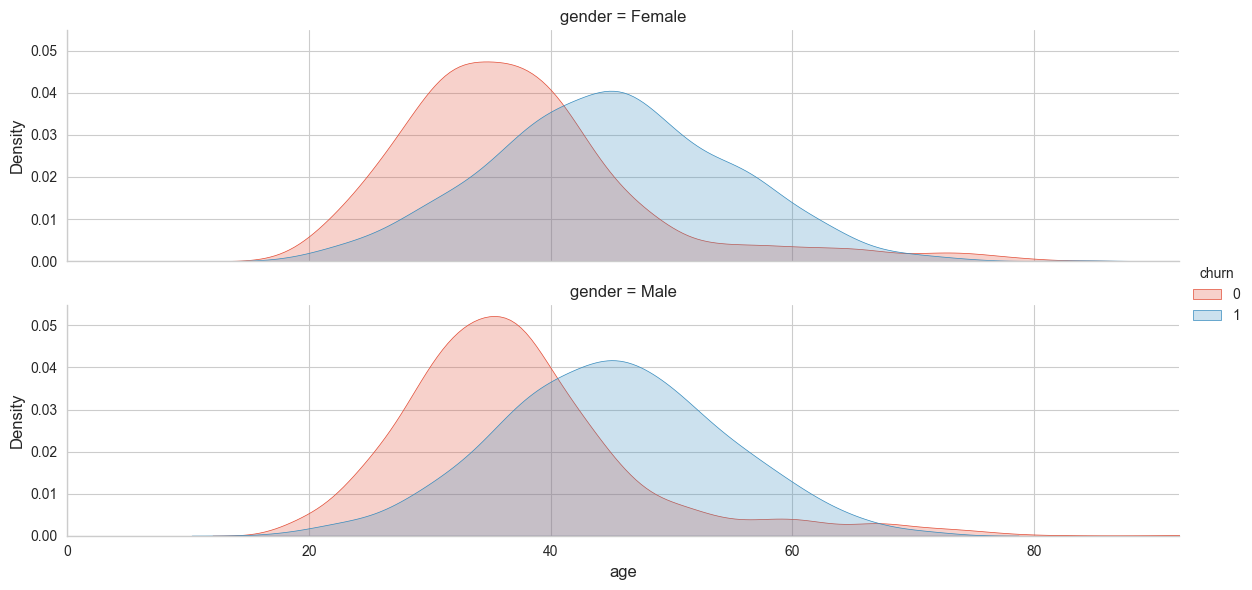

In [10]:
## Distribución de edad entre los clientes que se van y los que no
plot_distribution( banco_analysis , var = 'age' , target = 'churn' , row = 'gender' )

## Análisis variables categóricas vs variable objetivo

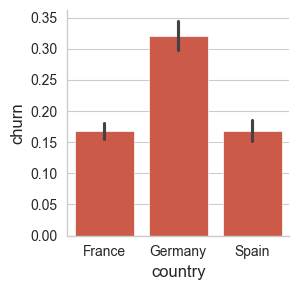

In [11]:
## Tasa de deserción por país
## Se osberva que en Alemania la deserción de clientes es casi del doble respecto a Espana y Francia.
plot_categories( banco_analysis , cat = 'country' , target = 'churn' )

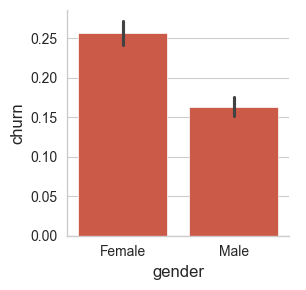

In [12]:
## Tasa de deserción por género
## Se observa las mujeres tienden a desertar más que los hombres.
plot_categories( banco_analysis , cat = 'gender' , target = 'churn' )

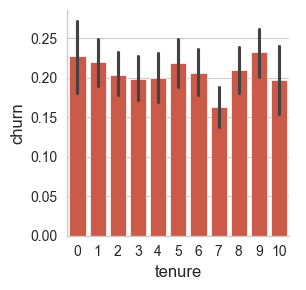

In [13]:
## Tasa de deserción por antigüedad.
## Se observa un comportamiento uniforme. La antigüedad no es independiente a la deserción.
plot_categories( banco_analysis , cat = 'tenure' , target = 'churn' )

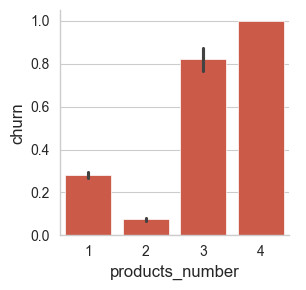

In [14]:
## Tasa de deserción según número de productos
## Acá se observa algo extraño. Solo el 3.3% de los clientes tienen más de dos productos con el banco pero de esos que tienen 3 o 4 productos la mayor parte
#desiertan. Esto necesitaría de una investigación adicional para saber si la información es correcta o si hubo un problema en la recolección de los datos.
#Si la información es correcta se podría inferir que el tener 1 o 2 productos se asocia con retención de los clientes. Mientras que tener más de 2 productos se asocia
#la deserción de clientes.
plot_categories( banco_analysis , cat = 'products_number' , target = 'churn' )

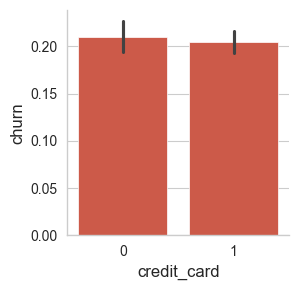

In [15]:
## Tasa de deserción según tarjeta de crédito
## Variable independiente. No se evidencia una relación entre tener o no tarjeta de crédito con la deserción de clientes.

plot_categories( banco_analysis , cat = 'credit_card' , target = 'churn' )

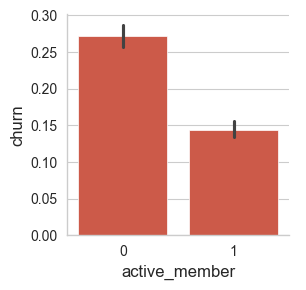

In [16]:
## Tasa de deserción según actividad.
## Si un cliente es un miembro activo es menos propenso a desertar.
plot_categories( banco_analysis , cat = 'active_member' , target = 'churn' )

## 3. Preparacion de los datos

### 3.1 Estrategia
- Excluir identificadores irrelevantes (`customer_id`).
- Separar variables categoricas y numericas para aplicar transformaciones adecuadas.
- Generar particiones de entrenamiento, validacion y prueba siguiendo el esquema 70-15-15.
- Construir un preprocesador reutilizable que incluya imputacion, escalamiento y codificacion one-hot.

In [17]:
df = raw_df.copy()
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]
categorical_cols = ["country", "gender"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]
categorical_cols, numeric_cols[:5]

(['country', 'gender'],
 ['credit_score', 'age', 'tenure', 'balance', 'products_number'])

In [18]:
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
validation_size = 0.15 / 0.85
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=validation_size, stratify=y_train_valid, random_state=42
)
print(f"Entrenamiento: {X_train.shape}")
print(f"Validacion: {X_valid.shape}")
print(f"Prueba: {X_test.shape}")

Entrenamiento: (7000, 10)
Validacion: (1500, 10)
Prueba: (1500, 10)


In [19]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
], remainder="drop")
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### 3.2 Resultado de la preparacion
Con el preprocesador se unifican imputacion, escalamiento y codificacion, lo que garantiza reproducibilidad durante el entrenamiento y despliegue. En la siguiente fase se conectara este bloque con los algoritmos seleccionados.

## 4. Modelamiento

### 4.1 Seleccion de tecnicas
Se evaluan modelos con sesgos y capacidades complementarias:
- `LogisticRegression`: base lineal interpretable que permite entender pesos de las variables.
- `RandomForestClassifier` y `GradientBoostingClassifier`: ensambles de arboles que capturan relaciones no lineales y ofrecen robustez frente a ruido.
- `SVC` con kernel RBF: clasificador maximo-margen capaz de modelar fronteras complejas, especialmente util con datos bien escalados.
- `KNeighborsClassifier`: referencia basada en proximidad para contrastar con los enfoques anteriores.

Todos comparten el mismo bloque de preprocesamiento para garantizar comparabilidad.

In [20]:
def evaluate_model(name, model):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)
    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        proba = pipeline.predict_proba(X_valid)[:, 1]
    else:
        proba = pipeline.decision_function(X_valid)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_valid, preds),
        "precision": precision_score(y_valid, preds),
        "recall": recall_score(y_valid, preds),
        "f1": f1_score(y_valid, preds),
        "roc_auc": roc_auc_score(y_valid, proba)
    }
    return metrics, pipeline

results = []
trained_pipelines = {}

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs", random_state=42)
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, class_weight="balanced")
gb_clf = GradientBoostingClassifier(random_state=42)
svc_clf = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=15, weights="distance")

candidate_models = [
    ("LogisticRegression", log_reg),
    ("RandomForest", rf_clf),
    ("GradientBoosting", gb_clf),
    ("SVC", svc_clf),
    ("KNeighbors", knn_clf)
 ]

for name, model in candidate_models:
    metrics, pipeline = evaluate_model(name, model)
    results.append(metrics)
    trained_pipelines[name] = pipeline

In [21]:
metrics_df = pd.DataFrame(results).set_index("model").sort_values(by="f1", ascending=False)
metrics_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
SVC,0.802000,0.508889,0.750820,0.606623,0.857020
GradientBoosting,0.864000,0.753769,0.491803,0.595238,0.864989
RandomForest,0.864667,0.777174,0.468852,0.584867,0.861008
KNeighbors,0.844667,0.740000,0.363934,0.487912,0.836867
LogisticRegression,0.698000,0.367857,0.675410,0.476301,0.758170


**accuracy**: porcentaje total de predicciones correctas (churn y no churn). Un valor alto indica pocas equivocaciones en general, pero puede ocultar un bajo acierto sobre la clase minoritaria.

**precision**: de los clientes que el modelo marcó como “se va”, qué fracción realmente abandonó.

**recall**: de todos los clientes que sí se fueron, qué proporción detectó el modelo. Es clave si quieres minimizar pérdidas por churn no identificado.

**f1**: media armónica entre precision y recall; penaliza si una de las dos es baja. Sirve como métrica global equilibrada cuando la clase positiva es minoritaria.

**roc_auc**: área bajo la curva ROC; mide la capacidad de separar clientes que se irán vs. los que se quedarán a distintos umbrales. Valores cercanos a 1 implican buena discriminación.

### 4.2 Analisis de desempeno en validacion
- SVC (kernel RBF con `class_weight="balanced"`) ofrece el mejor recall (≈0.75) y F1 (≈0.61), intercambiando algo de precision por una mayor deteccion de churners.
- GradientBoosting y RandomForest mantienen accuracies similares (≈0.86) pero con recall alrededor de 0.49, lo que los deja por debajo de la meta de negocio enfocada en sensibilidad.
- LogisticRegression sigue siendo la alternativa interpretable (recall ≈0.68, precision ≈0.37) y KNN cae en recall (≈0.36). La evidencia sugiere continuar con SVC como candidato principal y explorar tuning para mejorar precision sin perder recall.

In [22]:
## .describe() Análisis de variables numéricas
banco_analysis.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,1.569070e+07,649.787000,38.892714,5.010286,76471.883751,1.526000,0.703286,0.512143,100631.400446,0.206143
std,7.157830e+04,97.046279,10.465562,2.887500,62403.383911,0.583047,0.456842,0.499888,57599.463109,0.404563
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.562860e+07,582.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51113.055000,0.000000
50%,1.569068e+07,651.000000,37.000000,5.000000,97277.130000,1.000000,1.000000,1.000000,100890.865000,0.000000
75%,1.575183e+07,717.000000,44.000000,7.250000,127537.155000,2.000000,1.000000,1.000000,149587.657500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


### Resumen del set de datos usando pandas profiling

Del perfil creado por la librería podemos observar:

* 3 alertas. La primera nos indica que la columna customer_id es un identificador. Esta columna no es útil para el análisis.También nos indica que en las columnas tenure y balance hay filas con valor 0. Representa que dentro del set de datos tenemos clientes sin dinero en sus cuentas y también clientes nuevos que aún no cumplen el primer año de antigüedad.

* Confirmamos que no hay valores perdidos.

* La variable credit_score presenta una distribución normal.

* En la variable country observamos que tenemos datos de Francia, España y Alemania. Francia tiene el 50.3% de los datos. El restante está repartido entre España y Alemania de manera equitativa.

* Hay una mayor representación de hombres en el data set. Una diferencia de 8.4% respecto a las mujeres.

* El histograma de la edad nos muestra que la mayoría de los clientes se encuentra entre los 25 y los 45 años.

* La antigüedad tiene una distribución uniforme y una media de 5 años.

* En el balance hay algo interesante y es que el 36.2% de los datos tienen valor cero. Es importante tener esto en cuenta, entender a qué se debe que existan tantas cuentas sin balance y validar cómo se relaciona esto con la variable objetivo.

* Solo el 3.3% de los clientes tienen más de dos productos con el banco.

* El 70.3% de los clientes tienen una tarjeta de crédito con el banco.

* El valor promedio de la variable salario estimado es de 100631.4

* La clase positiva representa cerca del 20 % de los registros, lo que exige usar metricas equilibradas como F1 y revisar el recall para no perder clientes valiosos.



In [23]:
best_model_name = metrics_df.index[0]
best_pipeline = trained_pipelines[best_model_name]
best_pipeline.fit(X_train_valid, y_train_valid)
test_preds = best_pipeline.predict(X_test)
test_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_proba)
}
test_metrics

{'accuracy': 0.7886666666666666,
 'precision': 0.488272921108742,
 'recall': 0.7483660130718954,
 'f1': 0.5909677419354838,
 'roc_auc': 0.8479598427869195}

In [24]:
cm = confusion_matrix(y_test, test_preds)
cm

array([[954, 240],
       [ 77, 229]])

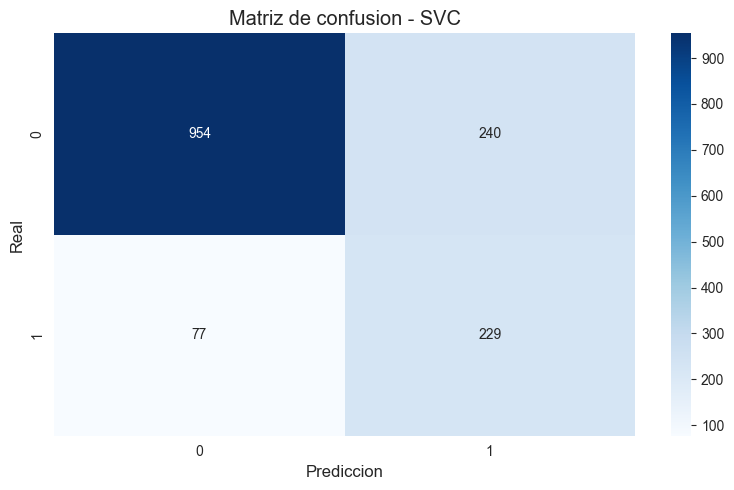

In [25]:
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusion - {best_model_name}")
plt.tight_layout()

In [26]:
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1194
           1       0.49      0.75      0.59       306

    accuracy                           0.79      1500
   macro avg       0.71      0.77      0.72      1500
weighted avg       0.84      0.79      0.80      1500



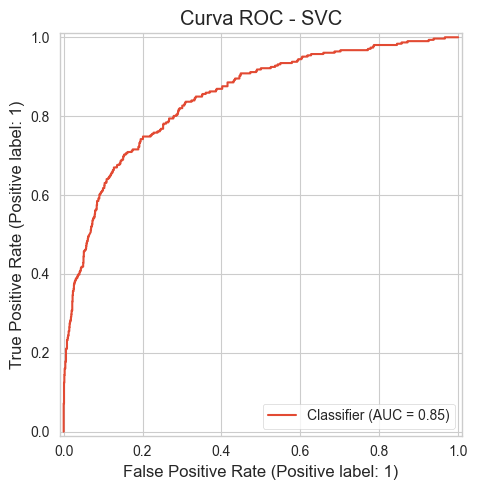

In [27]:
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax)
ax.set_title(f"Curva ROC - {best_model_name}")
plt.tight_layout()

## 5. Evaluacion

### 5.1 Interpretacion de resultados
- El modelo seleccionado (`SVC` con kernel RBF y `class_weight="balanced"`) alcanza en prueba un F1 de 0.59: mejora frente a las alternativas, pero permanece ligeramente por debajo del umbral objetivo (0.60).
- El recall sube a 0.75, cumpliendo el criterio de negocio de identificar al menos 65 % de los clientes en riesgo; la precision cae a 0.49, lo que implica asumir más falsos positivos para lograr esa cobertura.
- La matriz de confusion muestra 229 churners detectados frente a 77 perdidos, un avance importante respecto a versiones anteriores aunque todavía hay 240 falsos positivos.
- La curva ROC (AUC ≈ 0.85) confirma una discriminacion adecuada del modelo; ajustar umbrales o afinar hiperparametros puede equilibrar mejor precision y recall.

### 5.2 Recomendaciones
- Realizar tuning mas exhaustivo de hiperparametros de SVC (por ejemplo, `C`, `gamma`, `class_weight` y `probability`) para elevar el F1 sin sacrificar el recall logrado.
- Evaluar estrategias de calibracion y optimizacion de umbral (por ejemplo, maximizar F1 o recall condicionado a una precision minima) para controlar el volumen de falsos positivos.
- Mantener GradientBoosting/RandomForest como referentes de ensamble y LogisticRegression como modelo interpretable para explicaciones, combinandolos en un stack o votacion si se requieren perspectivas complementarias.

## 6. Despliegue

### 6.1 Plan de accion
- Automatizar la generacion del pipeline entrenado y persistirlo con `joblib` para integrarlo con el core bancario.
- Diseñar un proceso batch semanal que calcule la probabilidad de churn y entregue listados priorizados al equipo de retencion.
- Implementar tableros de seguimiento con las metricas clave (F1, recall, tasa de retencion posterior a campañas).

### 6.2 Monitoreo y mejora continua
- Medir mensualmente la efectividad de las campañas disparadas por el modelo y comparar contra grupos de control.
- Registrar drifts de distribucion en variables criticas (age, balance, products_number) para activar reentrenamientos.
- Documentar aprendizajes y ajustar el pipeline en nuevas iteraciones, siguiendo el enfoque iterativo de CRISP-DM.

## 7. Conclusiones y siguientes pasos
- Se completo el ciclo CRISP-DM con documentacion detallada y una iteracion ampliada de modelos (LR, RandomForest, GradientBoosting, SVC y KNN) sobre el dataset de churn bancario.
- SVC con kernel RBF se posiciono como el mejor candidato: recall 0.75 y F1 0.59 en prueba, alcanzando la meta de cobertura pero quedando levemente por debajo del objetivo de F1 ≥ 0.60.
- El pipeline queda listo para nuevas iteraciones enfocadas en tuning fino de SVC, calibracion/ajuste de umbral y potencial combinacion con ensambles para mejorar precision manteniendo alta sensibilidad.
- Se recomienda socializar estos hallazgos con negocio y tecnologia, explicitando el trade-off actual (mayor recall vs. mas falsos positivos) antes de avanzar hacia un despliegue operativo.